In [10]:
#Load Data 

housing_df = pd.read_csv('housing_data_binary_NLP.csv')
housing_df['log_latestPrice'] = np.log(housing_df['latestPrice'])

In [8]:
#Skewness and kurtosis

print("Skewness: %f" % housing_df['latestPrice'].skew())
print("Kurtosis: %f" % housing_df['latestPrice'].kurt())

Skewness: 4.096822
Kurtosis: 31.690568


In [9]:
#Skewness and kurtosis of log(latestPrice)

print("Skewness: %f" % housing_df['log_latestPrice'].skew())
print("Kurtosis: %f" % housing_df['log_latestPrice'].kurt())

Skewness: 0.326856
Kurtosis: 3.189001


In [ ]:
#Skewness and kurtosis are much better for log(latestprice), i.e, very close to normal distribution 

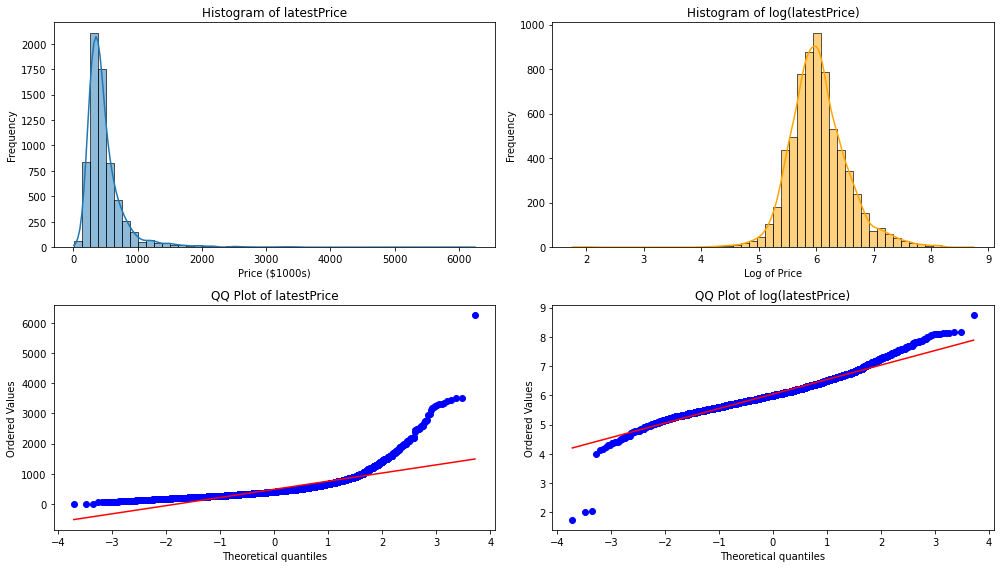

In [3]:
#Visualizing the distribution 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats



plt.figure(figsize=(14, 8))

# Histogram of original latestPrice
plt.subplot(2, 2, 1)
sns.histplot(housing_df['latestPrice'], bins=50, kde=True)
plt.title("Histogram of latestPrice")
plt.xlabel("Price ($1000s)")
plt.ylabel("Frequency")

# Histogram of log-transformed latestPrice
plt.subplot(2, 2, 2)
sns.histplot(housing_df['log_latestPrice'], bins=50, kde=True, color='orange')
plt.title("Histogram of log(latestPrice)")
plt.xlabel("Log of Price")
plt.ylabel("Frequency")

# QQ Plot of original latestPrice
plt.subplot(2, 2, 3)
stats.probplot(housing_df['latestPrice'], dist="norm", plot=plt)
plt.title("QQ Plot of latestPrice")

# QQ Plot of log-transformed latestPrice
plt.subplot(2, 2, 4)
stats.probplot(housing_df['log_latestPrice'], dist="norm", plot=plt)
plt.title("QQ Plot of log(latestPrice)")

plt.tight_layout()
plt.show()


In [15]:
#Checking for extreme values 


# Sort by lowest and highest prices
extreme_low = housing_df.sort_values(by='latestPrice').head(10)
extreme_high = housing_df.sort_values(by='latestPrice', ascending=False).head(10)

# Also check log-transformed values
extreme_log_low = housing_df.sort_values(by='log_latestPrice').head(10)
extreme_log_high = housing_df.sort_values(by='log_latestPrice', ascending=False).head(10)

# Display them
print("Lowest Prices:")
print(extreme_low[['latestPrice', 'log_latestPrice']])
print("\nHighest Prices:")
print(extreme_high[['latestPrice', 'log_latestPrice']])

print("\nLowest Log Prices:")
print(extreme_log_low[['latestPrice', 'log_latestPrice']])
print("\nHighest Log Prices:")
print(extreme_log_high[['latestPrice', 'log_latestPrice']])

Lowest Prices:
      latestPrice  log_latestPrice
311           5.8         1.757858
4136          7.5         2.014903
6523          7.9         2.066863
1791         55.0         4.007333
860          62.5         4.135167
2389         65.0         4.174387
4623         70.0         4.248495
1422         72.9         4.289089
4344         74.5         4.310799
4395         79.0         4.369448

Highest Prices:
      latestPrice  log_latestPrice
6542       6250.0         8.740337
6449       3500.0         8.160518
463        3499.0         8.160232
6227       3450.0         8.146130
559        3395.0         8.130059
2056       3349.0         8.116417
6548       3300.0         8.101678
6520       3295.0         8.100161
511        3275.0         8.094073
175        3250.0         8.086410

Lowest Log Prices:
      latestPrice  log_latestPrice
311           5.8         1.757858
4136          7.5         2.014903
6523          7.9         2.066863
1791         55.0         4.007333
860

In [ ]:
#Check for most correlation and analysing best features 

In [30]:
import pandas as pd

# Select numeric columns only (excluding the target itself)
numeric_features = housing_df.select_dtypes(include=['number']).columns.drop('latestPrice')
numeric_features = numeric_features.drop(['log_latestPrice','lotSizeSqFt', 'livingAreaSqFt','avgSchoolRating', 'avgSchoolSize'])

# Calculate correlations with the target
correlations = housing_df[numeric_features].corrwith(housing_df['log_latestPrice'])

# Filter features with |correlation| > 0.3
selected_features = correlations[correlations.abs() > 0.3].sort_values(ascending=False)

print("Selected features with |correlation| > 0.3:")
print(selected_features)


Selected features with |correlation| > 0.3:
log_livingAreaSqFt          0.555631
numOfBathrooms              0.488826
avgSchoolRating_sq          0.426939
log_lotSizeSqFt             0.405561
MedianStudentsPerTeacher    0.346328
numOfBedrooms               0.337346
dtype: float64


In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = housing_df[numeric_features]
X['const'] = 1  # Add constant for VIF

vif_data = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif_data = vif_data.sort_values(by='VIF', ascending=False)
print(vif_data[vif_data['VIF'] > 5])  # Flag high VIFs

C:\Users\ckshr\anaconda3\envs\myenv\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


                     Feature           VIF
82                     const  5.219672e+07
66              zipcode78748  6.470303e+01
0                   latitude  5.752625e+01
63              zipcode78745  5.193475e+01
43              zipcode78717  4.827440e+01
67              zipcode78749  4.275170e+01
60              zipcode78739  4.002145e+01
76              zipcode78759  3.473794e+01
1                  longitude  3.328932e+01
41              zipcode78704  3.317921e+01
46              zipcode78723  3.275391e+01
55              zipcode78732  3.207707e+01
59              zipcode78737  3.020658e+01
52              zipcode78729  2.901512e+01
71              zipcode78753  2.812383e+01
74              zipcode78757  2.800427e+01
50              zipcode78727  2.786538e+01
72              zipcode78754  2.685018e+01
62              zipcode78744  2.608622e+01
65              zipcode78747  2.426449e+01
54              zipcode78731  2.365308e+01
75              zipcode78758  2.334410e+01
38         

In [29]:
from scipy.stats import ttest_ind

binary_features = ['good_updated', 'good_luxurious', 'good_stainless',
       'good_basketball', 'good_landscaped', 'good_granite', 'good_pergola',
       'good_remodel', 'good_beautiful', 'good_tile', 'good_upgraded',
       'good_updated', 'good_greenbelt', 'bad_charming', 'bad_cozy',
       'bad_investment', 'bad_investor', 'bad_potential', 'bad_opportunity',
       'bad_nice']

for feature in binary_features:
    group_0 = housing_df[housing_df[feature] == 0]['log_latestPrice']
    group_1 = housing_df[housing_df[feature] == 1]['log_latestPrice']
    
    # Skip feature if one group is empty
    if len(group_0) == 0 or len(group_1) == 0:
        print(f"Skipping {feature} due to insufficient group size.")
        continue
    
    t_stat, p_value = ttest_ind(group_0, group_1, equal_var=False)
    
    print(f"Feature: {feature}")
    print(f"  T-statistic: {t_stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print("  => Significant difference detected — keep the feature.\n")
    else:
        print("  => No significant difference — consider dropping the feature.\n")

        


Feature: good_updated
  T-statistic: 3.0491
  P-value: 0.0023
  => Significant difference detected — keep the feature.

Feature: good_luxurious
  T-statistic: -8.1837
  P-value: 0.0000
  => Significant difference detected — keep the feature.

Feature: good_stainless
  T-statistic: 1.7730
  P-value: 0.0764
  => No significant difference — consider dropping the feature.

Feature: good_basketball
  T-statistic: 1.5969
  P-value: 0.1143
  => No significant difference — consider dropping the feature.

Feature: good_landscaped
  T-statistic: -2.1614
  P-value: 0.0320
  => Significant difference detected — keep the feature.

Feature: good_granite
  T-statistic: 3.6768
  P-value: 0.0002
  => Significant difference detected — keep the feature.

Feature: good_pergola
  T-statistic: -0.5900
  P-value: 0.5563
  => No significant difference — consider dropping the feature.

Feature: good_remodel
  T-statistic: -3.6334
  P-value: 0.0003
  => Significant difference detected — keep the feature.

Featu

In [ ]:
#Select features using Lasso regularization 

In [18]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = housing_df.drop(columns=['log_latestPrice', 'latestPrice','lotSizeSqFt', 'livingAreaSqFt','avgSchoolRating', 'avgSchoolSize']) # drop raw price if present
y = housing_df['log_latestPrice']

pipeline = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=42))
pipeline.fit(X, y)

# Get coefficients
coef = pipeline.named_steps['lassocv'].coef_
features = pd.Series(coef, index=X.columns)
selected = features[features != 0].sort_values(key=abs, ascending=False)
print("Selected features by Lasso:\n", selected)


Selected features by Lasso:
 yearsOld             -0.211376
log_livingAreaSqFt    0.197532
yearsOld_sq           0.181066
zipcode78704          0.124634
zipcode78703          0.096132
                        ...   
good_greenbelt       -0.001411
good_pergola          0.000543
numOfAppliances       0.000486
good_updated          0.000219
bad_charming         -0.000155
Length: 85, dtype: float64


In [28]:
selected_feature_names = selected.index.tolist()

In [29]:
#Run model on Lasso selected features 


import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


def run_linear_model(feature_list, df, target_col='log_latestPrice', test_size=0.3, random_state=42):
    # Split into X and y
    X = df[feature_list]
    y = df[target_col]
    
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    # Fit model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Predict
    y_pred_log = model.predict(X_test)
    
    # Log-scale metrics
    mse_log = mean_squared_error(y_test, y_pred_log)
    r2_log = r2_score(y_test, y_pred_log)
    
    # Convert predictions and actual values back to dollar scale
    y_pred_dollars = np.exp(y_pred_log)
    y_test_dollars = np.exp(y_test)
    
    # Dollar-scale metrics
    mse_dollars = mean_squared_error(y_test_dollars, y_pred_dollars)
    rmse_dollars = np.sqrt(mse_dollars)
    
    # Print results
#     print(f"Features used: {feature_list}")
    print(f"--- Log Scale ---")
    print(f"Test MSE (log scale): {mse_log:.4f}")
    print(f"Test R² (log scale): {r2_log:.4f}")
    print(f"--- Dollar Scale ---")
    print(f"Test MSE (dollars): ${mse_dollars:,.2f}")
    print(f"Test RMSE (dollars): ${rmse_dollars:,.2f}")
    
    return model


run_linear_model(selected_feature_names, housing_df)

--- Log Scale ---
Test MSE (log scale): 0.0614
Test R² (log scale): 0.7629
--- Dollar Scale ---
Test MSE (dollars): $33,337.27
Test RMSE (dollars): $182.58


LinearRegression()

In [39]:
#Run Lasso regression on all features 

from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

def run_lasso_model(df, target_col='log_latestPrice', test_size=0.3, random_state=42):
    # Split data
    X = df.drop(columns=['log_latestPrice', 'latestPrice','lotSizeSqFt', 'livingAreaSqFt','avgSchoolRating', 'avgSchoolSize']) # drop raw price if present

    y = df[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    # Fit Lasso with cross-validation to choose alpha
    lasso = LassoCV(cv=5, random_state=random_state)
    lasso.fit(X_train, y_train)
    
    # Predict on log scale
    y_pred_log = lasso.predict(X_test)
    
    # Metrics on log scale
    mse_log = mean_squared_error(y_test, y_pred_log)
    r2_log = r2_score(y_test, y_pred_log)
    
    # Convert back to dollars
    y_pred_dollars = np.exp(y_pred_log)
    y_test_dollars = np.exp(y_test)
    
    mse_dollars = mean_squared_error(y_test_dollars, y_pred_dollars)
    rmse_dollars = np.sqrt(mse_dollars)
    
    print(f"LassoCV selected alpha: {lasso.alpha_:.4f}")
    print(f"--- Log Scale ---")
    print(f"MSE (log): {mse_log:.4f}")
    print(f"R² (log): {r2_log:.4f}")
    print(f"--- Dollar Scale ---")
    print(f"MSE (dollars): ${mse_dollars:,.2f}")
    print(f"RMSE (dollars): ${rmse_dollars:,.2f}")
    
    return lasso


In [40]:
# feature_cols = housing_df.drop(columns=['log_latestPrice', 'latestPrice','lotSizeSqFt', 'livingAreaSqFt','avgSchoolRating', 'avgSchoolSize'])

run_lasso_model(housing_df)

LassoCV selected alpha: 0.0657
--- Log Scale ---
MSE (log): 0.1485
R² (log): 0.4270
--- Dollar Scale ---
MSE (dollars): $87,301.09
RMSE (dollars): $295.47


LassoCV(cv=5, random_state=42)

In [41]:
from sklearn.linear_model import RidgeCV

def run_ridge_model(df, target_col='log_latestPrice', test_size=0.3, random_state=42):
    X = df.drop(columns=['log_latestPrice', 'latestPrice','lotSizeSqFt', 'livingAreaSqFt','avgSchoolRating', 'avgSchoolSize']) # drop raw price if present

    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    # RidgeCV with cross-validation over a range of alphas
    alphas = np.logspace(-4, 4, 100)
    ridge = RidgeCV(alphas=alphas, cv=5)
    ridge.fit(X_train, y_train)
    
    y_pred_log = ridge.predict(X_test)
    
    # Log scale
    mse_log = mean_squared_error(y_test, y_pred_log)
    r2_log = r2_score(y_test, y_pred_log)
    
    # Dollar scale
    y_pred_dollars = np.exp(y_pred_log)
    y_test_dollars = np.exp(y_test)
    
    mse_dollars = mean_squared_error(y_test_dollars, y_pred_dollars)
    rmse_dollars = np.sqrt(mse_dollars)
    
    print(f"RidgeCV selected alpha: {ridge.alpha_:.4f}")
    print(f"--- Log Scale ---")
    print(f"MSE (log): {mse_log:.4f}")
    print(f"R² (log): {r2_log:.4f}")
    print(f"--- Dollar Scale ---")
    print(f"MSE (dollars): ${mse_dollars:,.2f}")
    print(f"RMSE (dollars): ${rmse_dollars:,.2f}")
    
    return ridge


In [42]:
run_ridge_model(housing_df)

RidgeCV selected alpha: 0.2984
--- Log Scale ---
MSE (log): 0.0612
R² (log): 0.7637
--- Dollar Scale ---
MSE (dollars): $33,144.58
RMSE (dollars): $182.06


RidgeCV(alphas=array([1.00000000e-04, 1.20450354e-04, 1.45082878e-04, 1.74752840e-04,
       2.10490414e-04, 2.53536449e-04, 3.05385551e-04, 3.67837977e-04,
       4.43062146e-04, 5.33669923e-04, 6.42807312e-04, 7.74263683e-04,
       9.32603347e-04, 1.12332403e-03, 1.35304777e-03, 1.62975083e-03,
       1.96304065e-03, 2.36448941e-03, 2.84803587e-03, 3.43046929e-03,
       4.13201240e-03, 4.97702356e-0...
       1.38488637e+02, 1.66810054e+02, 2.00923300e+02, 2.42012826e+02,
       2.91505306e+02, 3.51119173e+02, 4.22924287e+02, 5.09413801e+02,
       6.13590727e+02, 7.39072203e+02, 8.90215085e+02, 1.07226722e+03,
       1.29154967e+03, 1.55567614e+03, 1.87381742e+03, 2.25701972e+03,
       2.71858824e+03, 3.27454916e+03, 3.94420606e+03, 4.75081016e+03,
       5.72236766e+03, 6.89261210e+03, 8.30217568e+03, 1.00000000e+04]),
        cv=5)